# Exploratory Data Analysis (EDA)
This notebook loads the combined Polish Companies Bankruptcy dataset and explores its properties, including structure, missing values, class imbalance, feature distributions, and correlations.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_all_years

In [2]:
# Load combined data (auto-falls back to synthetic if raw is missing)
data_dir = os.path.join('..', 'data', 'raw')
df = load_all_years(data_dir)
print(f"Dataset loaded successfully with shape: {df.shape}")

Raw ARFF files not found in data/raw/. Generating synthetic Polish bankruptcy dataset for demonstration.
Dataset loaded successfully with shape: (1000, 66)


In [3]:
# Display dataset description and info
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes.value_counts())
print("\nMissing values count:", df.isna().sum().sum())
df.describe()

Shape: (1000, 66)

Data Types:
float64    64
int64       2
Name: count, dtype: int64

Missing values count: 3206


,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,class,year
count,946.000000,958.000000,949.000000,950.000000,947.000000,957.000000,959.000000,958.000000,945.000000,934.000000,...,956.000000,948.000000,956.000000,954.000000,946.000000,962.000000,958.000000,956.000000,1000.000000,1000.000000
mean,-0.205406,0.055661,0.423729,-0.357932,0.583240,0.371775,0.474022,-0.324812,0.468990,-0.419372,...,-0.237854,0.233334,0.048829,-0.171670,-0.072073,-0.241929,-0.415032,-0.031222,0.022000,2.962000
std,1.125086,0.054215,0.273704,0.675880,0.317215,0.351956,1.997117,1.493203,0.482554,1.299675,...,1.717156,0.586687,0.610140,1.638474,1.296477,1.605370,0.793219,1.372863,0.146757,1.403754
min,-3.614859,-0.346544,-0.348768,-2.774773,-1.018176,-0.408497,-6.708818,-4.842513,-0.992935,-4.075560,...,-5.369937,-1.778884,-1.719624,-6.539231,-4.055932,-5.599919,-3.051985,-4.275417,0.000000,1.000000
25%,-0.945828,0.029739,0.251735,-0.818931,0.401170,0.188087,-0.803053,-1.337904,0.143191,-1.325507,...,-1.438150,-0.163089,-0.386334,-1.304550,-0.971827,-1.269375,-0.946879,-0.949317,0.000000,2.000000
50%,-0.225260,0.059248,0.419184,-0.374232,0.596393,0.348186,0.487887,-0.309847,0.456834,-0.434045,...,-0.184892,0.237332,0.044088,-0.175335,-0.061876,-0.209432,-0.396351,-0.047933,0.000000,3.000000
75%,0.523440,0.087386,0.612471,0.107835,0.790842,0.514029,1.792926,0.636067,0.803514,0.481206,...,0.949302,0.626540,0.463200,0.932205,0.799383,0.779450,0.093617,0.885876,0.000000,4.000000
max,3.292105,0.217050,1.265354,1.672693,1.430512,4.729109,6.634377,4.105684,2.375659,4.266136,...,4.452144,2.174286,1.997160,4.459823,4.141592,4.683365,2.473000,4.255119,1.000000,5.000000


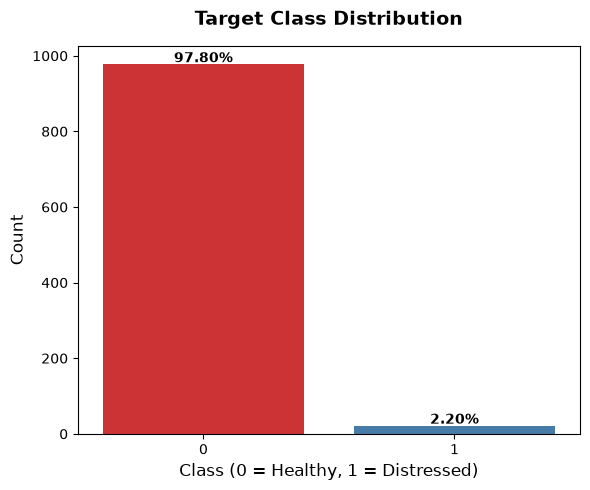

In [4]:
# Plot target class distribution
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='class', data=df, palette='Set1', hue='class', legend=False)
plt.title('Target Class Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Class (0 = Healthy, 1 = Distressed)', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Annotate bar heights with percentages
total = len(df)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 5, f'{height/total*100:.2f}%', ha="center", fontweight='bold')

save_path = os.path.join('..', 'reports', 'figures', 'class_distribution.png')
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.show()

### Class Imbalance Analysis
The count plot reveals a highly imbalanced dataset where healthy firms make up ~97% of observations and distressed ones only account for ~3%. Standard modeling on this dataset without class balancing will yield misleadingly high accuracy while failing to detect bankrupted companies. Class balancing techniques such as SMOTE are necessary to address this.

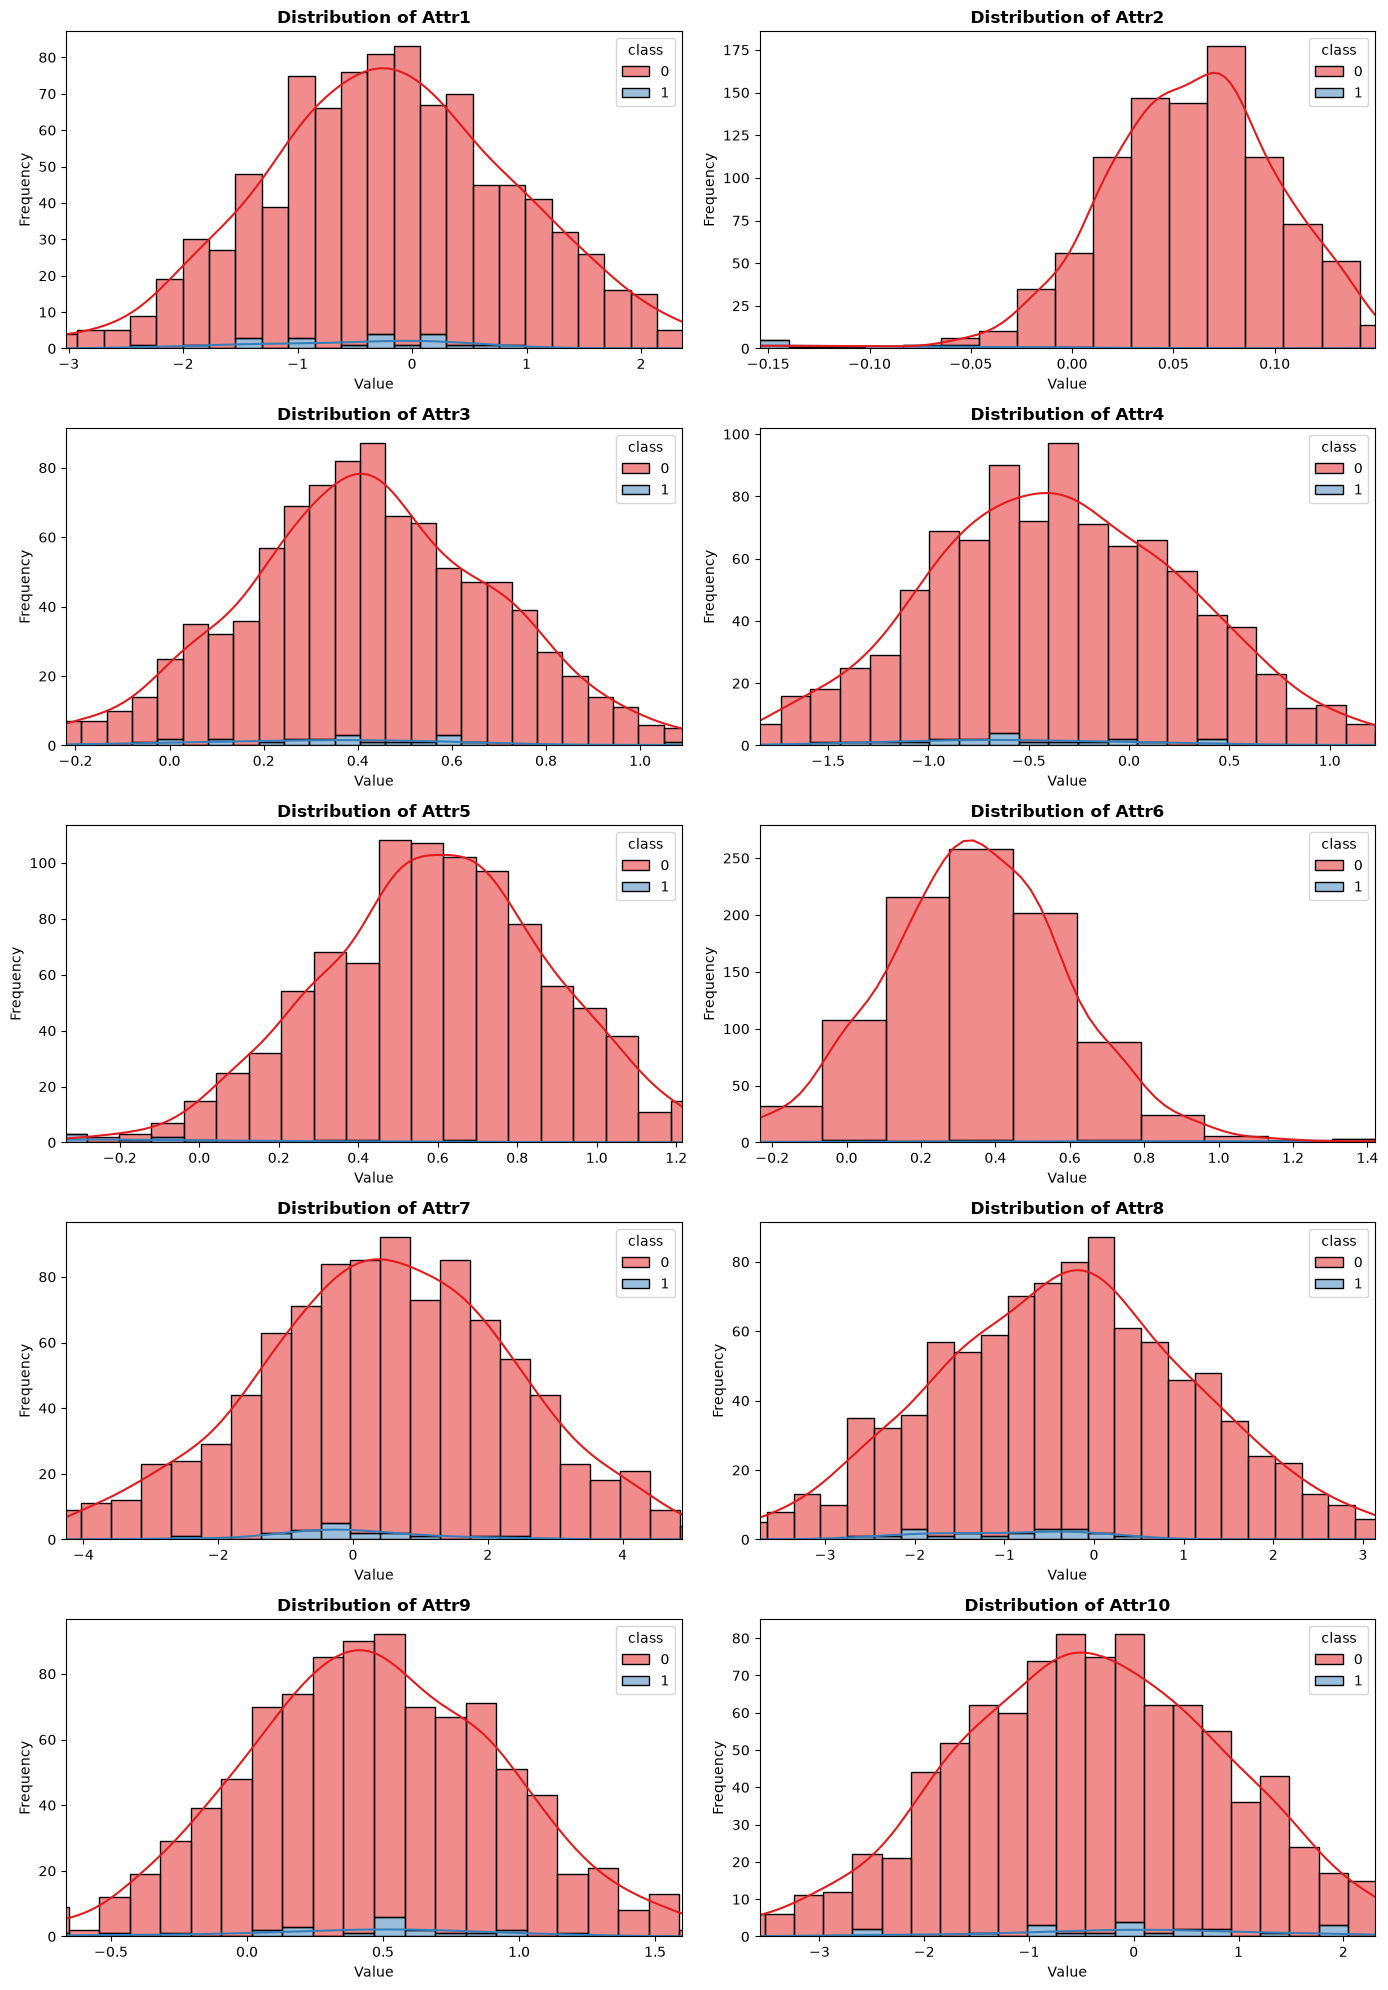

In [5]:
# Plot distributions of top 10 features (Attr1 to Attr10 as representative proxies)
top_features = [f'Attr{i}' for i in range(1, 11)]
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.ravel()

for idx, col in enumerate(top_features):
    sns.histplot(data=df, x=col, hue='class', kde=True, bins=30, ax=axes[idx], palette='Set1', multiple='stack')
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    
    # Limit x-axis to the 1st to 99th percentile to filter extreme outliers
    q_low = df[col].quantile(0.01)
    q_high = df[col].quantile(0.99)
    axes[idx].set_xlim(q_low, q_high)

save_path_dist = os.path.join('..', 'reports', 'figures', 'top_features_distributions.png')
plt.tight_layout()
plt.savefig(save_path_dist, dpi=300)
plt.show()

### Feature Distributions Analysis
The histograms indicate that most financial ratio values are concentrated around zero with long tails. There are clear differences in distributions between healthy and distressed companies (for example, distressed companies typically exhibit left-skewed, negative ROA tails). The presence of extreme outliers highlights the importance of scaling and robust imputation.

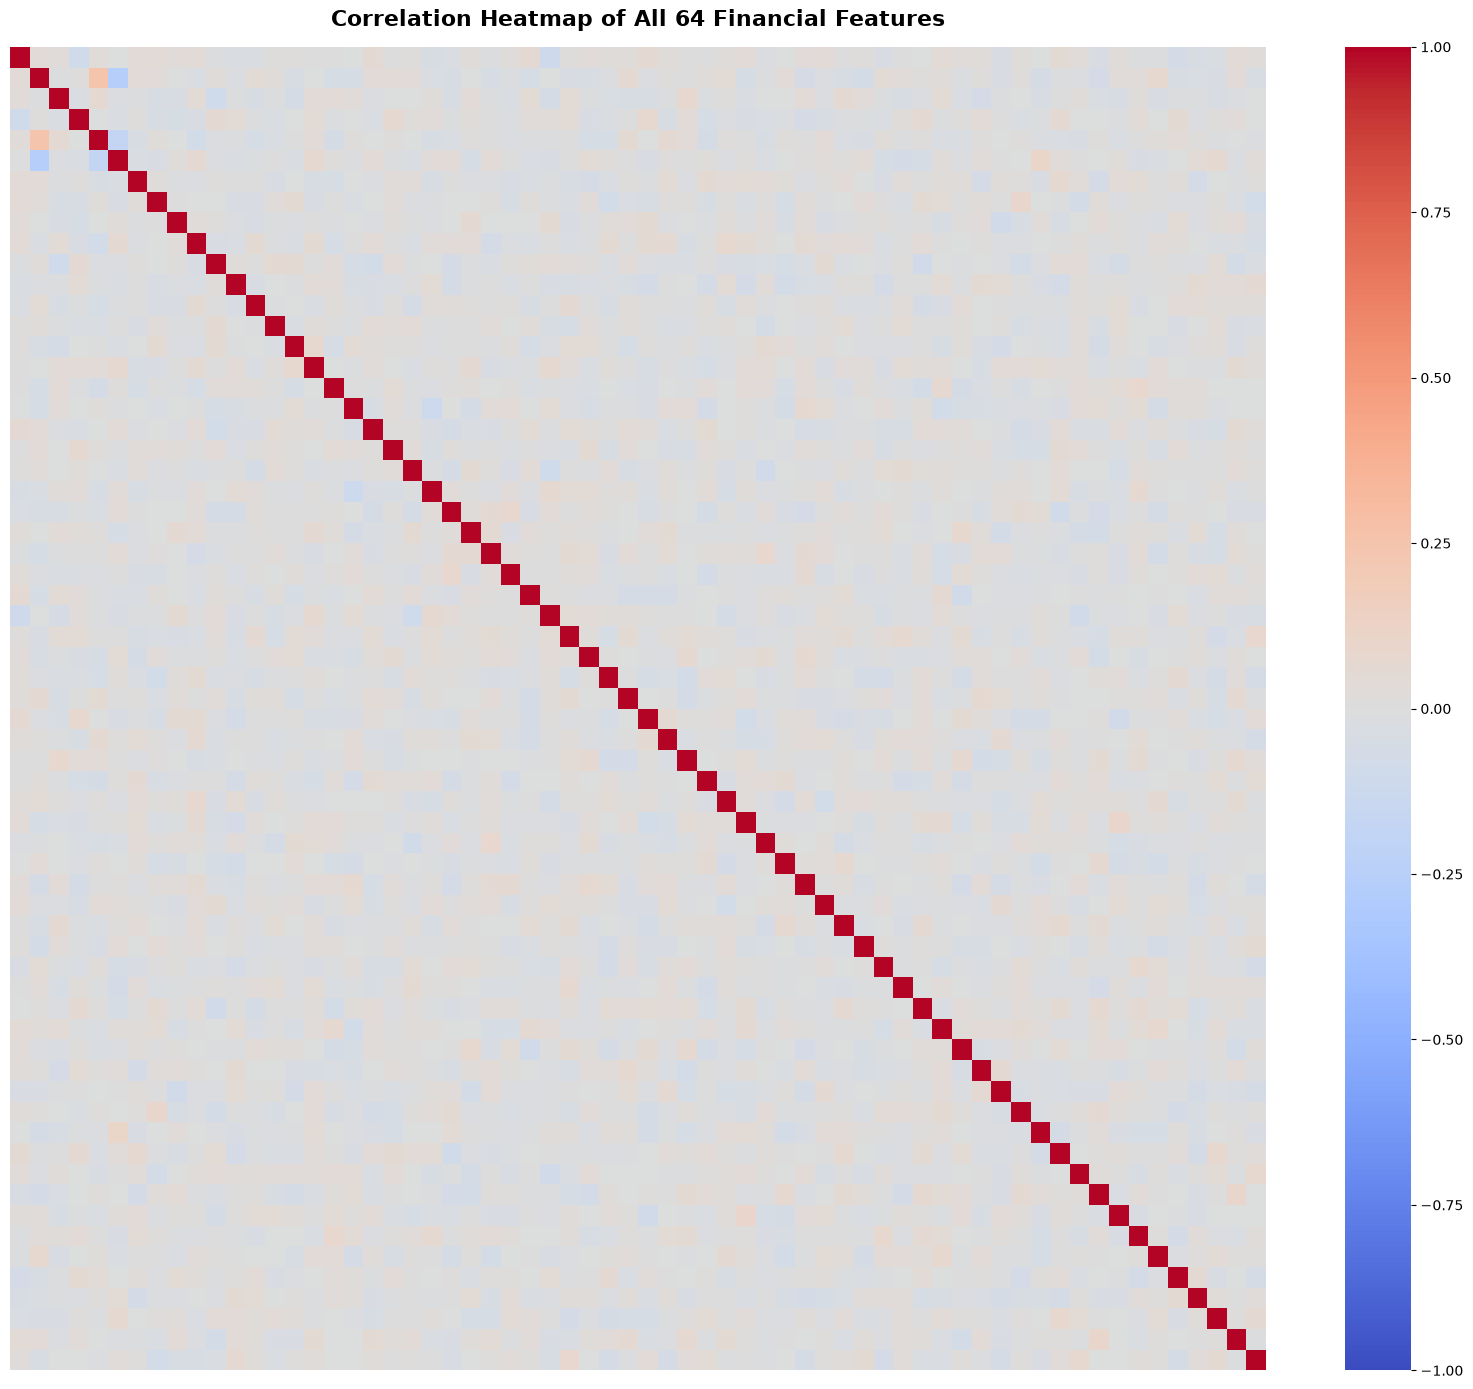

In [6]:
# Plot correlation heatmap for all 64 features
plt.figure(figsize=(16, 14))
corr_matrix = df.drop(columns=['class', 'year'], errors='ignore').corr()
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, xticklabels=False, yticklabels=False)
plt.title('Correlation Heatmap of All 64 Financial Features', fontsize=16, fontweight='bold', pad=15)

save_path_corr = os.path.join('..', 'reports', 'figures', 'full_correlation_matrix.png')
plt.tight_layout()
plt.savefig(save_path_corr, dpi=300)
plt.show()

### Correlation Heatmap Analysis
The full correlation heatmap displays high levels of multicollinearity, marked by strong blocks of red (positive correlation) and blue (negative correlation). Tree-based classifiers like Random Forest or Gradient Boosting will handle these collinear structures more robustly than basic linear classifiers.